In [1]:
# Initial import

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import and load the dataset

df = pd.read_csv("Walmart.csv")
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [3]:
# Correcting the date columns

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.dtypes

Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [4]:
# Step 2 Aggregate total sales over time

daily_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
daily_sales.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [8]:
daily_sales.tail()

,Date,Weekly_Sales
138,2012-09-28,43734899.40
139,2012-10-05,47566639.31
140,2012-10-12,46128514.25
141,2012-10-19,45122410.57
142,2012-10-26,45544116.29


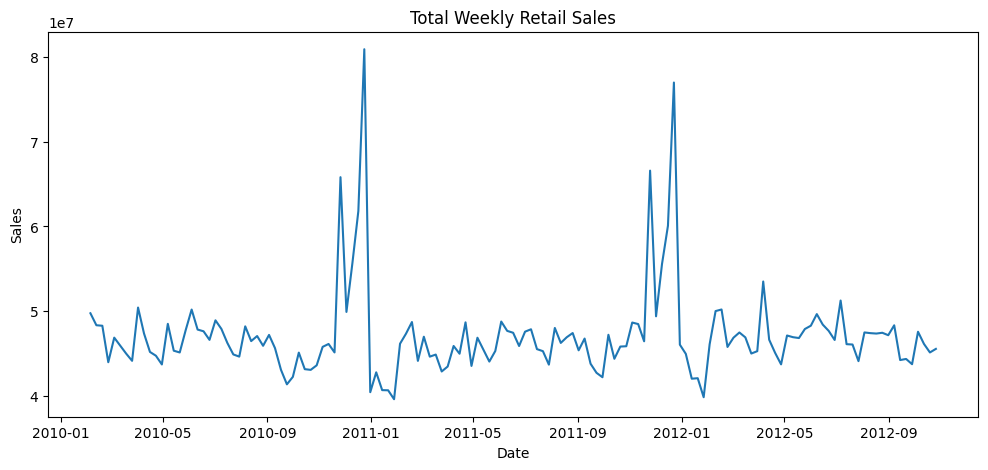

In [7]:
# Step 3 Plot Series

plt.figure(figsize=(12,5))
plt.plot(daily_sales['Date'], daily_sales['Weekly_Sales'])
plt.title("Total Weekly Retail Sales")
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

Weekly retail sales show strong annual seasonality with pronounced holiday spikes followed by post-season corrections. Baseline demand remains stable across years, suggesting predictable cyclical behavior suitable for forecasting.

In [11]:
# Step 4 Prepare data for Prophet
prophet_df = daily_sales.rename(columns={
    'Date': 'ds',
    'Weekly_Sales': 'y'})
prophet_df.head()

,ds,y
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [12]:
# Step 5 Train Prophet model

from prophet import Prophet

model = Prophet()
model.fit(prophet_df)

17:39:25 - cmdstanpy - INFO - Chain [1] start processing
17:39:25 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
# Step 6 Forecast the next 12 weeks

future = model.make_future_dataframe(periods=12, freq='w')

forecast = model.predict(future)

forecast.tail()
                                     

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
150,2012-12-16,4.831383e+07,6.038220e+07,6.919495e+07,4.830850e+07,4.831833e+07,1.649612e+07,1.649612e+07,1.649612e+07,1.649612e+07,1.649612e+07,1.649612e+07,0.0,0.0,0.0,6.480995e+07
151,2012-12-23,4.832693e+07,5.938999e+07,6.836055e+07,4.832071e+07,4.833218e+07,1.531022e+07,1.531022e+07,1.531022e+07,1.531022e+07,1.531022e+07,1.531022e+07,0.0,0.0,0.0,6.363716e+07
152,2012-12-30,4.834003e+07,5.193517e+07,6.049649e+07,4.833275e+07,4.834626e+07,7.879115e+06,7.879115e+06,7.879115e+06,7.879115e+06,7.879115e+06,7.879115e+06,0.0,0.0,0.0,5.621915e+07
153,2013-01-06,4.835314e+07,4.165614e+07,5.039197e+07,4.834451e+07,4.836072e+07,-2.221730e+06,-2.221730e+06,-2.221730e+06,-2.221730e+06,-2.221730e+06,-2.221730e+06,0.0,0.0,0.0,4.613141e+07
154,2013-01-13,4.836624e+07,3.453699e+07,4.383903e+07,4.835636e+07,4.837492e+07,-9.018944e+06,-9.018944e+06,-9.018944e+06,-9.018944e+06,-9.018944e+06,-9.018944e+06,0.0,0.0,0.0,3.934729e+07


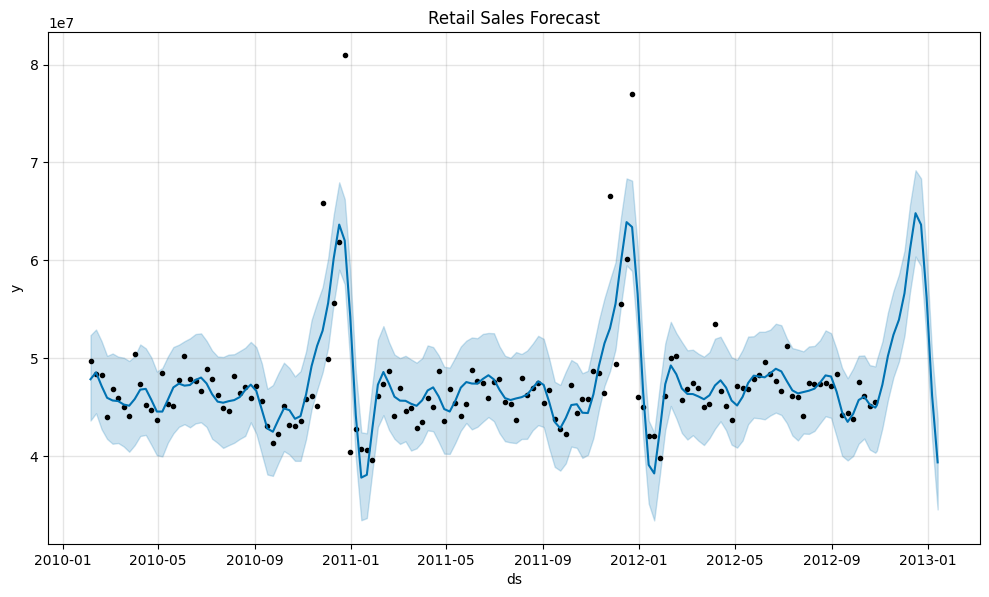

In [14]:
# Step 7 Plot Forecast

fig = model.plot(forecast)
plt.title("Retail Sales Forecast")
plt.show()

### Interpretation
The model successfully captures strong yearly retail seasonality, particularly holiday spikes followed by post-season corrections. Forecasts extend this repeating structure, enabling short-term demand planning with realistic uncertainty bounds.

In [16]:
# Step 8 Model evaluation

train = prophet_df[:-12]
test = prophet_df[-12:]

m = Prophet()
m.fit(train)

future = m.make_future_dataframe(periods=12, freq='W')
fcst = m.predict(future)

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test['y'], fcst.tail(12)['yhat']))
print("RMSE:", rmse)

14:15:23 - cmdstanpy - INFO - Chain [1] start processing
14:15:23 - cmdstanpy - INFO - Chain [1] done processing


RMSE: 1212351.3921901125


### Interpretation
The Prophet model achieved an RMSE of approximately $1.2M, representing ~2–3% of average weekly sales. This indicates strong predictive performance given the magnitude and volatility of retail demand.

In [18]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train['y'], order=(5,1,0))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=12)

arima_rmse = np.sqrt(mean_squared_error(test['y'], arima_forecast))
print("ARIMA RMSE:", arima_rmse)

ARIMA RMSE: 1627515.3251754644


In [19]:
holidays = df[df['Holiday_Flag'] == 1][['Date']]
holidays.columns = ['ds']
holidays['holiday'] = 'holiday'

model = Prophet(holidays=holidays)
model.fit(prophet_df)

16:38:07 - cmdstanpy - INFO - Chain [1] start processing
16:38:07 - cmdstanpy - INFO - Chain [1] done processing


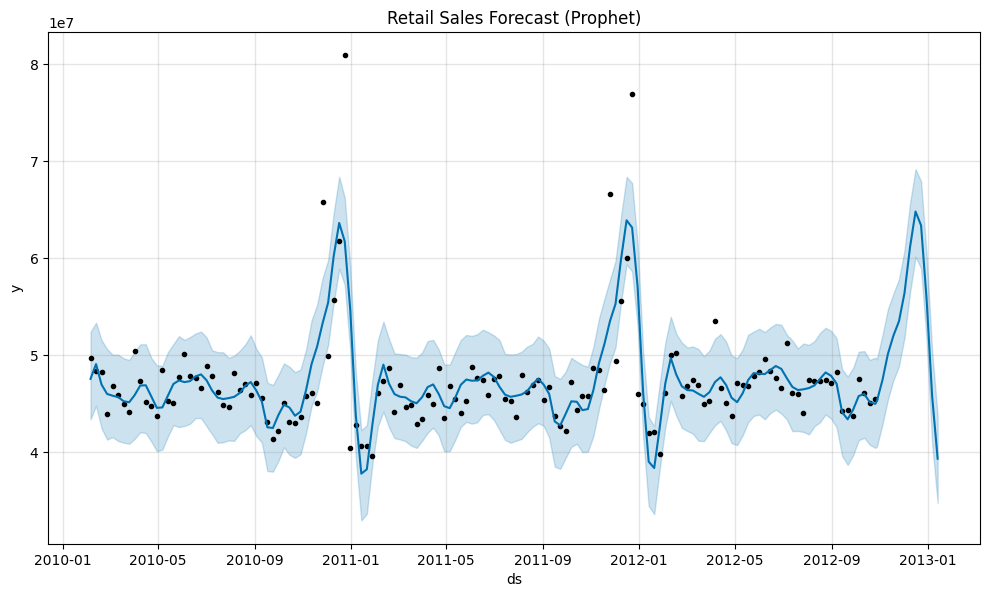

In [24]:
future = model.make_future_dataframe(periods=12, freq='W')
forecast = model.predict(future)

fig1 = model.plot(forecast)
plt.title("Retail Sales Forecast (Prophet)")
plt.show()

In [27]:
import os
os.makedirs("visuals", exist_ok=True)

In [28]:
fig1.savefig("visuals/forecast_plot.png",dpi=200, bbox_inches="tight")

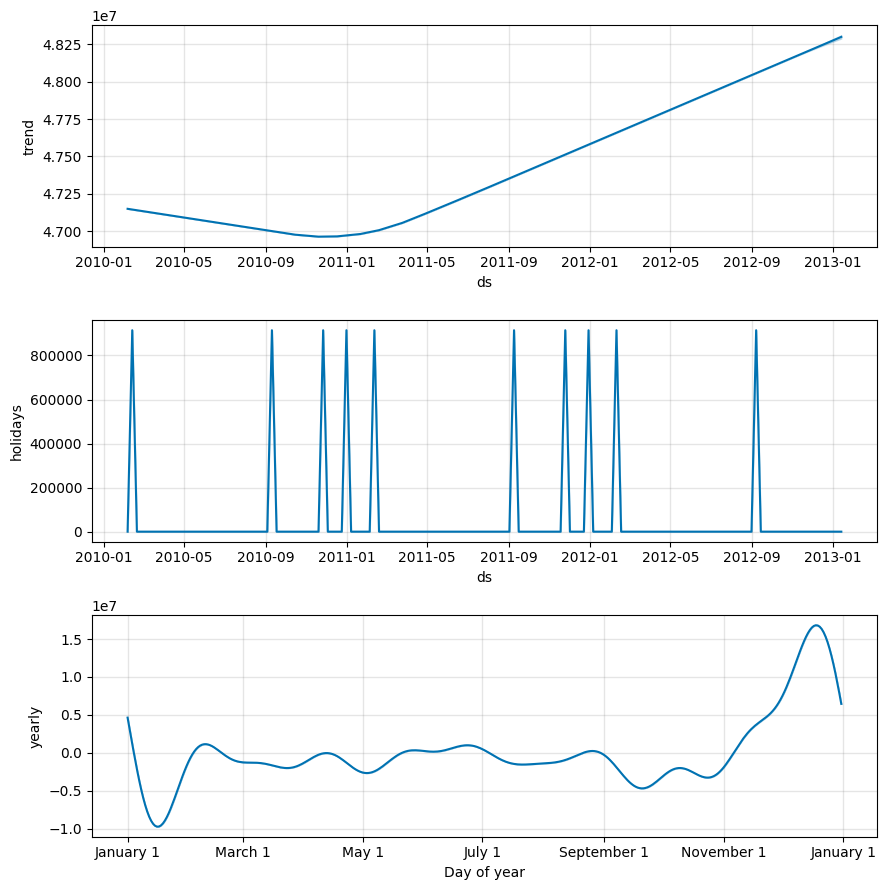

In [32]:
fig2 = model.plot_components(forecast)
plt.show()

In [33]:
fig2.savefig("visuals/forecast_components.png", dpi=200, bbox_inches="tight")

In [34]:
os.listdir("visuals")

['forecast_components.png', 'forecast_plot.png']

In [35]:
['forecast_plot.png', 'forecast_components.png']

['forecast_plot.png', 'forecast_components.png']